# eigenfaces: class dataset

same pipeline as the olivetti notebook, but applied to our own photos. 26 people, 3 images each.

to reduce bias from lighting, hair, and framing, we keep the preprocessing simple:
- center-crop each image
- convert to grayscale
- equalize contrast
- apply a face-centered mask

since we only have 3 images per person, we use **leave-one-out**: 2 images per person go to training, 1 to testing.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image, ImageOps
from sklearn.decomposition import PCA

IMG_SIZE = (128, 128)
CLASS_PATH = "class_pictures_cropped"
CELEB_PATH = "celebrity_pictures_cropped"


def load_dataset(root):
    X_display, X_math, y, label_map = [], [], [], {}

    for idx, person in enumerate(sorted(os.listdir(root))):
        person_dir = os.path.join(root, person)
        if not os.path.isdir(person_dir):
            continue
        label_map[idx] = person

        for fname in sorted(os.listdir(person_dir)):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            path = os.path.join(person_dir, fname)
            img = Image.open(path).convert("L").resize(IMG_SIZE, Image.Resampling.LANCZOS)

            # --- DISPLAY PATH ---
            # Mild histogram equalization just for display clarity.
            # We use autocontrast (not full equalize) so the face looks
            # like a natural photo rather than a blown-out contrast print.
            img_display = ImageOps.autocontrast(img, cutoff=1)
            arr_display = np.array(img_display, dtype=np.float32) / 255.0

            # --- MATH PATH (used for PCA) ---
            # Z-score normalization without equalize.
            # Skipping ImageOps.equalize here because it destroys relative
            # luminance differences between people, which PCA relies on to
            # separate identities. Z-score alone is sufficient to center and
            # scale each face for stable covariance computation.
            arr_math = np.array(img, dtype=np.float32) / 255.0
            arr_math = (arr_math - arr_math.mean()) / (arr_math.std() + 1e-8)

            X_display.append(arr_display.flatten())
            X_math.append(arr_math.flatten())
            y.append(idx)

    return np.array(X_display), np.array(X_math), np.array(y), label_map

X_display, X_math, y, label_map = load_dataset(CLASS_PATH)
print(f"loaded: {X_math.shape} | people: {len(label_map)}")

loaded: (76, 16384) | people: 26


## 1. explore the data

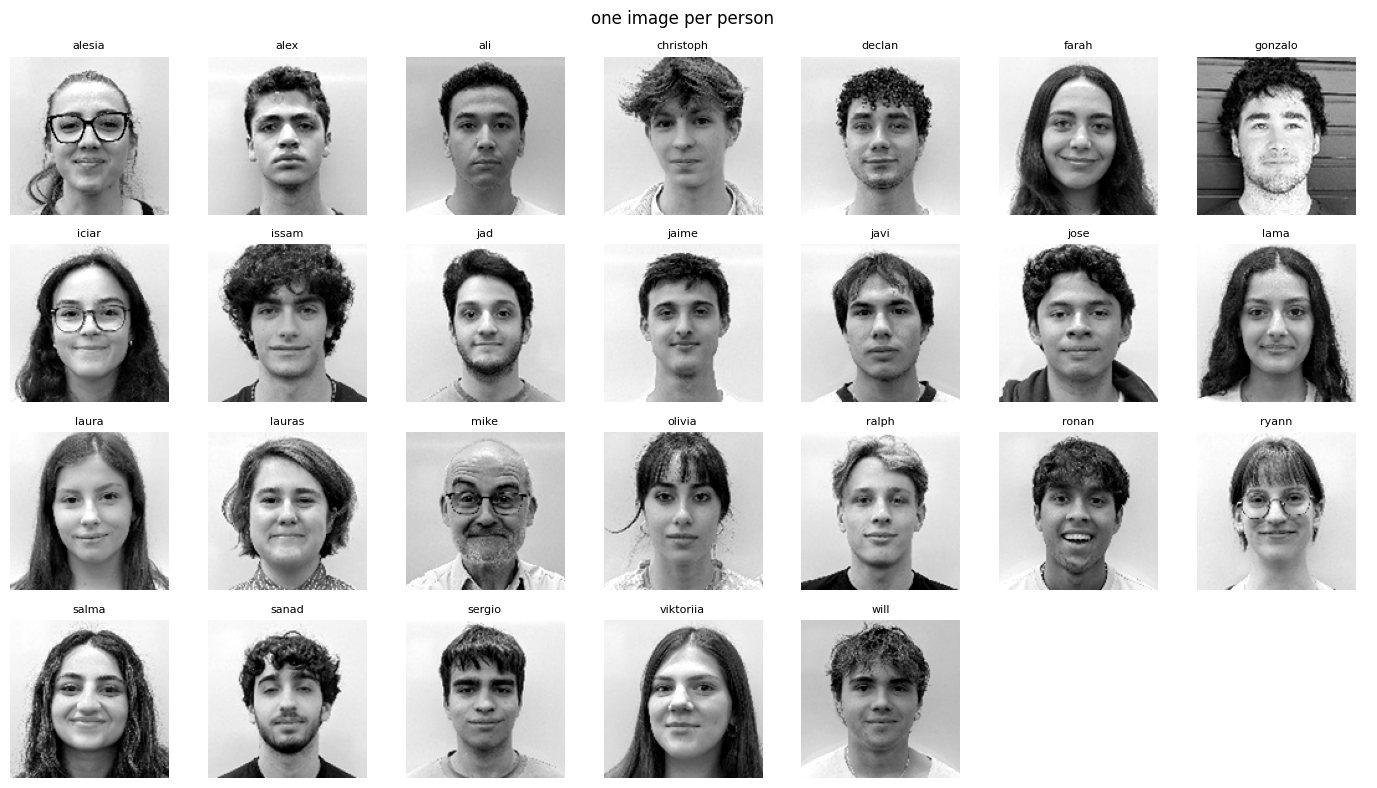

In [41]:
n_people = len(label_map)
fig, axes = plt.subplots(4, 7, figsize=(14, 8))

for i, ax in enumerate(axes.flat):
    if i >= n_people:
        ax.axis("off")
        continue
    person_idx = np.where(y == i)[0][0]
    ax.imshow(X_display[person_idx].reshape(IMG_SIZE), cmap="gray", vmin=0, vmax=1)
    ax.set_title(label_map[i], fontsize=8)
    ax.axis("off")

plt.suptitle("one image per person")
plt.tight_layout()
plt.show()

## 2. leave-one-out split

with only 3 images per person, a random split would give some people 0 test images. instead we take the last image of each person as the test sample, and use the first 2 for training.

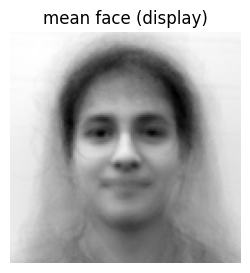

train: (50, 16384) | test: (26, 16384)


In [42]:
train_idx, test_idx = [], []

for person_id in np.unique(y):
    idxs = np.where(y == person_id)[0]
    train_idx.extend(idxs[:-1])
    test_idx.append(idxs[-1])

X_train_display, X_test_display = X_display[train_idx], X_display[test_idx]
X_train, y_train = X_math[train_idx], y[train_idx]
X_test, y_test = X_math[test_idx], y[test_idx]

mean_face = X_train.mean(axis=0)
X_train_c = X_train - mean_face
X_test_c = X_test - mean_face

plt.figure(figsize=(3, 3))
plt.imshow(X_train_display.mean(axis=0).reshape(IMG_SIZE), cmap="gray")
plt.title("mean face (display)")
plt.axis("off")
plt.show()

print(f"train: {X_train.shape} | test: {X_test.shape}")

## 3. pca — eigenfaces

we use:
- a larger $k$ for reconstruction, so the rebuilt faces stay close to the original
- a smaller $k$ for matching, so similarity focuses more on stable facial structure and less on noise, hair, and expression

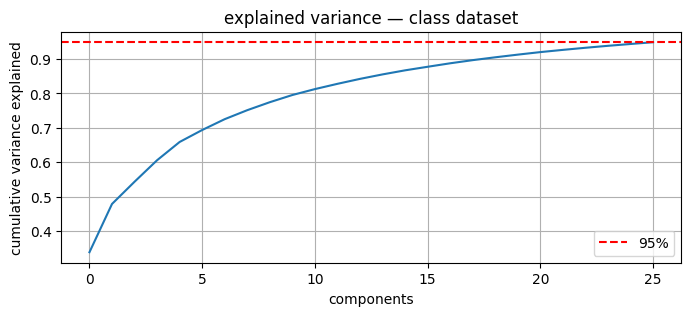

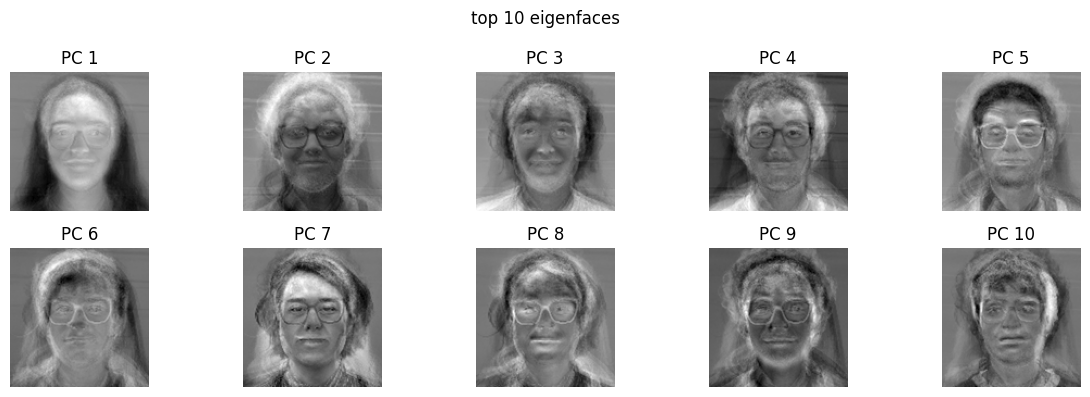

In [43]:
K = 26

pca = PCA(n_components=K, svd_solver="randomized", whiten=False)
pca.fit(X_train_c)
eigenfaces = pca.components_

plt.figure(figsize=(8, 3))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(0.95, color="red", linestyle="--", label="95%")
plt.xlabel("components")
plt.ylabel("cumulative variance explained")
plt.title("explained variance — class dataset")
plt.legend()
plt.grid(True)
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i].reshape( IMG_SIZE,), cmap="gray")
    ax.set_title(f"PC {i+1}")
    ax.axis("off")
plt.suptitle("top 10 eigenfaces")
plt.tight_layout()
plt.show()

## 4. face reconstruction

reconstruct every test face using the PCA basis.

for each row:
- left = original image
- right = reconstruction

we also show a cosine similarity score between the original test vector and its reconstruction.

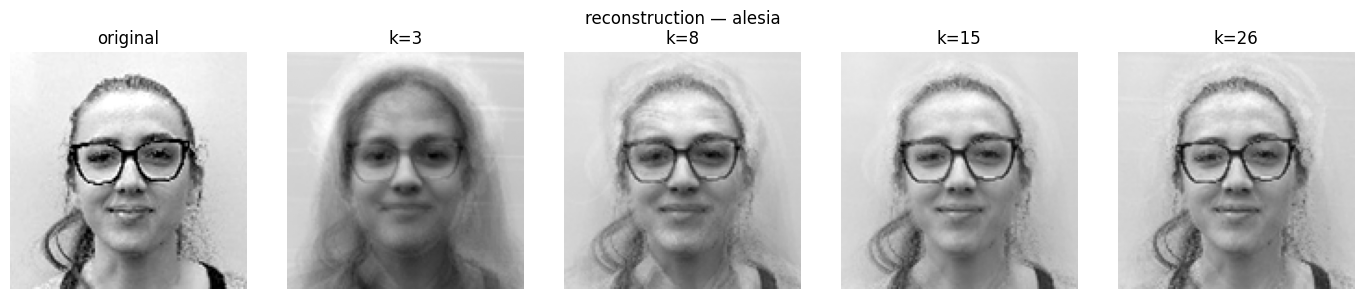

In [44]:
display_mean_face = X_train_display.mean(axis=0)

def reconstruct(X_c, components, mean):
    weights = X_c @ components.T
    return weights @ components + mean

k_show = [3, 8, 15, 26]
sample_c = X_test_c[[0]]
sample_orig = X_test_display[0]

fig, axes = plt.subplots(1, len(k_show) + 1, figsize=(14, 3))
axes[0].imshow(sample_orig.reshape(IMG_SIZE), cmap="gray")
axes[0].set_title("original")
axes[0].axis("off")

for ax, k_val in zip(axes[1:], k_show):
    rec_math = reconstruct(sample_c, eigenfaces[:k_val], mean_face)
    # shift back toward display appearance
    rec = rec_math - rec_math.min()
    rec = rec / (rec.max() + 1e-8)
    ax.imshow(rec.reshape(IMG_SIZE), cmap="gray")
    ax.set_title(f"k={k_val}")
    ax.axis("off")

plt.suptitle(f"reconstruction — {label_map[y_test[0]]}")
plt.tight_layout()
plt.show()

## 5. classmate similarity

first, we check the original self-identification task again as a baseline.

then, for the actual similarity task, we compare each test face to the **other classmates only**.

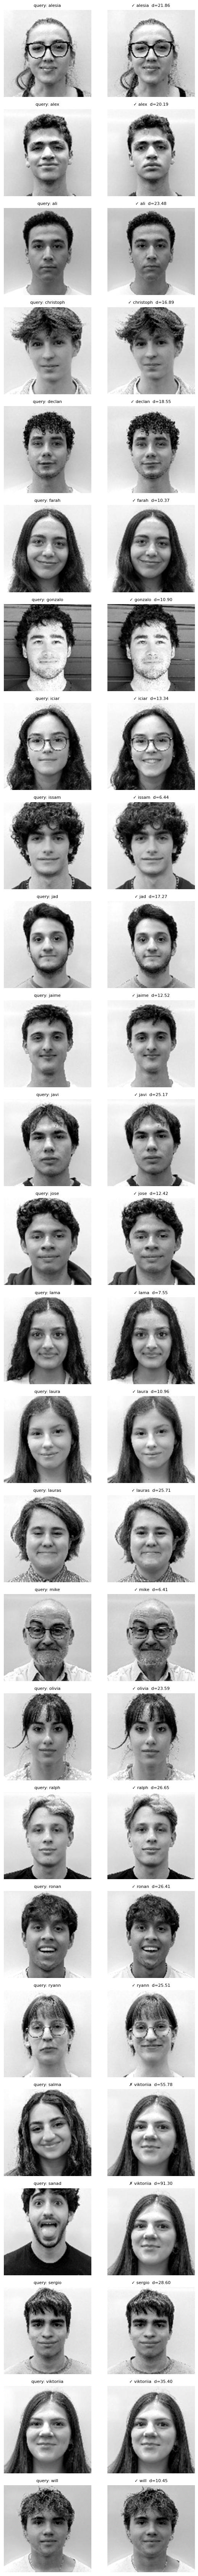

accuracy: 92.31% (24/26 correct)


In [45]:
train_weights = X_train_c @ eigenfaces.T

def recognize(query_c):
    dists = np.linalg.norm(train_weights - (query_c @ eigenfaces.T), axis=1)
    idx = np.argmin(dists)
    return y_train[idx], dists[idx], idx

fig, axes = plt.subplots(len(y_test), 2, figsize=(6, len(y_test) * 2.6))

for row, i in enumerate(range(len(X_test_c))):
    pred, dist, match_idx = recognize(X_test_c[[i]])
    true_lbl = y_test[i]
    mark = "✓" if pred == true_lbl else "✗"

    query_img = X_test_display[i].reshape(IMG_SIZE)
    match_img = X_train_display[match_idx].reshape(IMG_SIZE)

    axes[row, 0].imshow(query_img, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"query: {label_map[true_lbl]}", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(match_img, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(f"{mark} {label_map[pred]}  d={dist:.2f}", fontsize=8)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

preds = [recognize(X_test_c[[i]])[0] for i in range(len(X_test_c))]
accuracy = np.mean(np.array(preds) == y_test)
print(f"accuracy: {accuracy:.2%} ({int(accuracy*len(y_test))}/{len(y_test)} correct)")

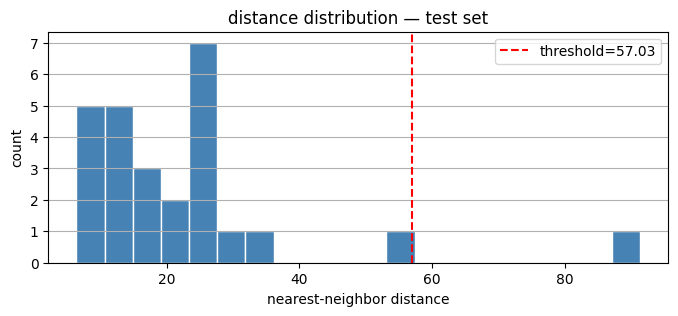

In [46]:
distances_test = np.array([
    np.linalg.norm(train_weights - (X_test_c[[i]] @ eigenfaces.T), axis=1).min()
    for i in range(len(X_test_c))
])

threshold = distances_test.mean() + 2 * distances_test.std()

plt.figure(figsize=(8, 3))
plt.hist(distances_test, bins=20, color="steelblue", edgecolor="white")
plt.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.2f}")
plt.xlabel("nearest-neighbor distance")
plt.ylabel("count")
plt.title("distance distribution — test set")
plt.legend()
plt.grid(True, axis="y")
plt.show()

## 6. celebrity comparison

project the celebrity images into the **classmate eigenspace** (the same PCA basis fitted in step 3),
so both groups live in a space defined by classmate facial variation.

for each classmate we show:
- the most similar **same-gender classmate** (excluding self)
- the top-2 most similar **same-gender celebrities**

similarity is cosine distance on PCs 1–K (PC0 skipped as a global brightness axis).

In [47]:
X_celeb_display, X_celeb, y_celeb, celeb_map = load_dataset(CELEB_PATH)
print(f"celebs loaded: {X_celeb.shape} | people: {len(celeb_map)}")

# classmate genders keyed by folder name -- verify these
CLASSMATE_GENDER = {
    "alesia": "F", "alex": "M", "ali": "M", "christoph": "M",
    "declan": "M", "farah": "F", "gonzalo": "M", "iciar": "F",
    "issam": "M", "jad": "M", "jaime": "M", "javi": "M",
    "jose": "M", "lama": "F", "laura": "F", "lauras": "F",
    "mike": "M", "olivia": "F", "ralph": "M", "ronan": "M",
    "ryann": "F", "salma": "F", "sanad": "M", "sergio": "M",
    "viktoriia": "F", "will": "M",
}

# celebrity genders keyed by folder name
CELEB_GENDER = {
    "Adam_Sandler": "M", "Al_Pacino": "M", "Anne_Hathaway": "F",
    "Ariana_Grande": "F", "AuronPLay": "M", "Bad_Bunny": "M",
    "Beyonce": "F", "Bill_Gates": "M", "Billie_Eilish": "F",
    "Brad_Pitt": "M", "Carlos_Alcaraaz": "M", "Charles_Lecleric": "M",
    "Chris_Hemsworth": "M", "Cristiano_Ronaldo": "M", "Donald_Trump": "M",
    "Drake": "M", "Einsten": "M", "Elon_Musk": "M",
    "Emma_Watson": "F", "Epstein": "M", "Felipe_VI": "M",
    "Freddie_Mercury": "M", "George_clooney": "M", "Gordan_Ramsay": "M",
    "Greta_Thunberg": "F", "Helena_Bonham_Carter": "F", "Ian_Somerhalder": "M",
    "Ice_Spice": "F", "Ilia_Topuria": "M", "Jack_Black": "M",
    "Jacob_Elordi": "M", "Jake_Paul": "M", "Jenna_Ortega": "F",
    "Jennifer_Lawrence": "F", "Jim_Carrey": "M", "Jimmy_Fallon": "M",
    "Johnny_Depp": "M", "Julia_Roberts": "F", "Justin_Bieber": "M",
    "Kai_Cenat": "M", "Kanye_West": "M", "Katy_Perry": "F",
    "Kendall_Jenner": "F", "Kevin_Hart": "M", "Kim_Jong-un": "M",
    "Kim_Kardashian": "F", "Lady_Gaga": "F", "Lamine_Yamal": "M",
    "Leonardo_DiCaprio": "M", "Lewis_Hamilton": "M", "Maluma": "M",
    "Marecelo": "M", "Max_Verstappen": "M", "Messi": "M",
    "Michael_Jackson": "M", "Miley_Cyrus": "F", "Mr_Bean": "M",
    "Mr_Beast": "M", "Natalie_Portman": "F", "Obama": "M",
    "Pablo_Escobar": "M", "Papa_Francisco": "M", "Pedro_Pascal": "M",
    "Pedro_Sanchez": "M", "Queen_England": "F", "Robert_De_Niro": "M",
    "Robert_Downey_Jr": "M", "Rosalia": "F", "Ryan_Gosling": "M",
    "Ryan_Reynolds": "M", "Salma_Hayek": "F", "Selena_Gomez": "F",
    "Shakira": "F", "Snoop_Dogg": "M", "Steve_Jobs": "M",
    "Taylor_Swift": "F", "The_Rock": "M", "Timothee_Chalamet": "M",
    "Tini": "F", "Tom_Cruise": "M", "Travis-Scott": "M",
    "Will_Smith": "M", "Zac_Efron": "M", "Zendaya": "F",
}

# project celebrities into the classmate eigenspace using the classmate mean from step 2
X_celeb_c = X_celeb - mean_face

# skip PC0 (global brightness)
PC_START, PC_END = 1, 18 # this param can be tuned 
components_use = eigenfaces[PC_START:PC_END]


def row_normalize(W):
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    norms[norms < 1e-8] = 1.0
    return W / norms


train_weights_c6 = row_normalize(X_train_c @ components_use.T)
celeb_weights_c6 = row_normalize(X_celeb_c @ components_use.T)


celebs loaded: (82, 16384) | people: 82


In [48]:
def get_gender(name, is_celeb=False):
    d = CELEB_GENDER if is_celeb else CLASSMATE_GENDER
    return d.get(name)  # none means unknown


def match_to_classmate(query_w, query_label, query_gender):
    best_sim, best_idx, best_lbl = -np.inf, None, None
    for i, w in enumerate(train_weights_c6):
        lbl = y_train[i]
        if lbl == query_label:
            continue
        other_gender = get_gender(label_map[lbl])
        # filter by gender only when both sides are known
        if query_gender and other_gender and query_gender != other_gender:
            continue
        sim = np.dot(query_w, w)
        if sim > best_sim:
            best_sim, best_idx, best_lbl = sim, i, lbl
    return best_lbl, best_sim, best_idx


def match_to_top2_celebrities(query_w, query_gender):
    results = []
    for i, w in enumerate(celeb_weights_c6):
        celeb_gender = get_gender(celeb_map[y_celeb[i]], is_celeb=True)
        # filter by gender only when both sides are known
        if query_gender and celeb_gender and query_gender != celeb_gender:
            continue
        results.append((y_celeb[i], float(np.dot(query_w, w)), i))
    results.sort(key=lambda x: x[1], reverse=True)
    return results[:2]


def similarity_score_0_10(cosine_sim):
    return float(np.clip((cosine_sim + 1) / 2 * 10, 0, 10))


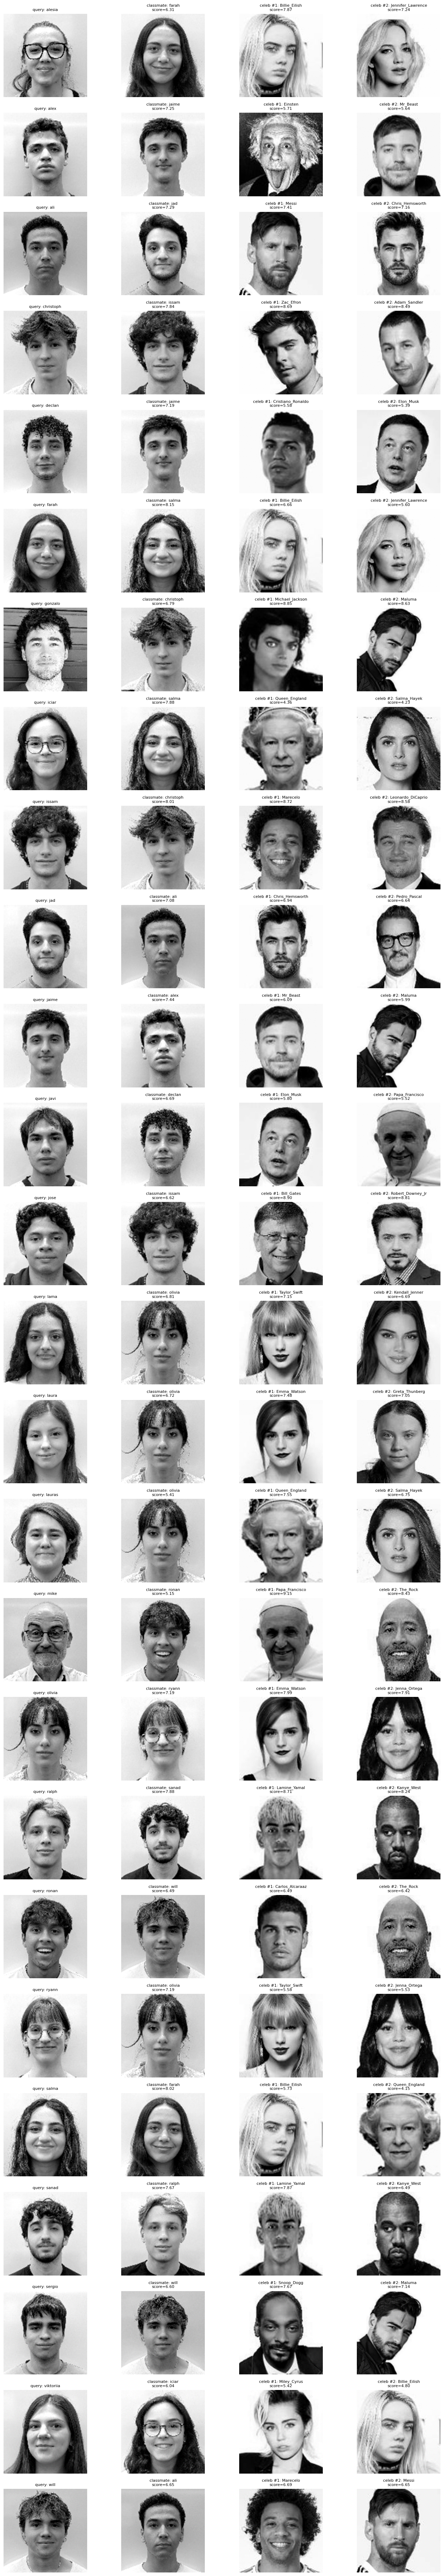

In [49]:
unique_people = sorted(set(y_train))

# pick the first training image of each person as their display card
person_display_idx = {pid: np.where(y_train == pid)[0][0] for pid in unique_people}

# average PCA weights across all training images per person, then re-normalize
person_avg_w = {}
for pid in unique_people:
    idxs = np.where(y_train == pid)[0]
    avg = train_weights_c6[idxs].mean(axis=0)
    norm = np.linalg.norm(avg)
    person_avg_w[pid] = avg / norm if norm > 1e-8 else avg

fig, axes = plt.subplots(len(unique_people), 4, figsize=(14, len(unique_people) * 2.8))

for row, pid in enumerate(unique_people):
    q_w = person_avg_w[pid]
    query_gender = get_gender(label_map[pid])

    # col 0: query person
    axes[row, 0].imshow(X_train_display[person_display_idx[pid]].reshape(IMG_SIZE), cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"query: {label_map[pid]}", fontsize=8)
    axes[row, 0].axis("off")

    # col 1: closest same-gender classmate (excluding self)
    class_lbl, class_sim, class_idx = match_to_classmate(q_w, pid, query_gender)
    axes[row, 1].imshow(X_train_display[class_idx].reshape(IMG_SIZE), cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(
        f"classmate: {label_map[class_lbl]}\nscore={similarity_score_0_10(class_sim):.2f}",
        fontsize=8,
    )
    axes[row, 1].axis("off")

    # cols 2 & 3: top-2 same-gender celebrities
    celeb_matches = match_to_top2_celebrities(q_w, query_gender)
    for col, (c_lbl, c_sim, c_idx) in enumerate(celeb_matches, start=2):
        axes[row, col].imshow(X_celeb_display[c_idx].reshape(IMG_SIZE), cmap="gray", vmin=0, vmax=1)
        axes[row, col].set_title(
            f"celeb #{col - 1}: {celeb_map[c_lbl]}\nscore={similarity_score_0_10(c_sim):.2f}",
            fontsize=8,
        )
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()


## 7. Class live demo

In [50]:
def show_classmate_and_celebrity(classmate_name):
    lookup = classmate_name.strip().lower()
    pid = name_to_pid.get(lookup)

    if pid is None:
        print(f"'{classmate_name}' not found. try one of: {', '.join(name_options)}")
        return

    q_w = person_avg_w[pid]
    query_gender = get_gender(label_map[pid])

    celeb_lbl, celeb_sim, celeb_idx = match_to_top2_celebrities(q_w, query_gender)[0]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # query classmate
    axes[0].imshow(X_train_display[person_display_idx[pid]].reshape(IMG_SIZE), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"classmate: {label_map[pid]}")
    axes[0].axis("off")

    # closest celebrity only
    axes[1].imshow(X_celeb_display[celeb_idx].reshape(IMG_SIZE), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(
        f"closest celebrity\n{celeb_map[celeb_lbl]}\nscore={similarity_score_0_10(celeb_sim):.2f}"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

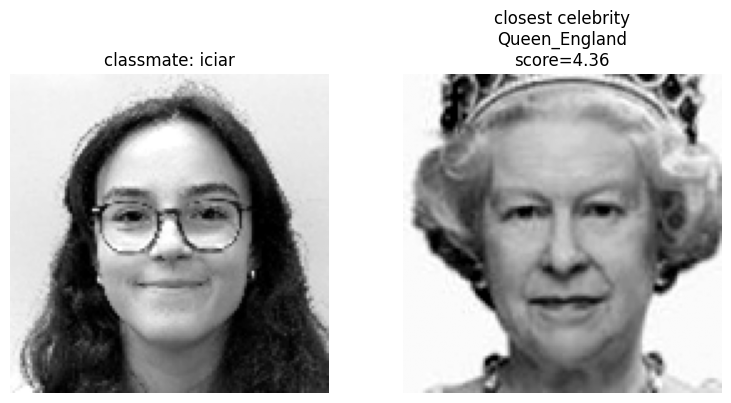

In [51]:
show_classmate_and_celebrity("iciar")

In [52]:
import ipywidgets as widgets
from IPython.display import display

picker = widgets.Dropdown(options=name_options, description="classmate:")
out = widgets.interactive_output(show_classmate_and_celebrity, {"classmate_name": picker})
display(picker, out)

Dropdown(description='classmate:', options=('alesia', 'alex', 'ali', 'christoph', 'declan', 'farah', 'gonzalo'…

Output()